Notebook 5 - Sensitivity Analysis

In [11]:
from pathlib import Path
root = Path.cwd()
if not (root / "data").is_dir() and (root.parent / "data").is_dir():
    root = root.parent
data = root / "data"

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cvxpy as cp
from hmmlearn.hmm import GaussianHMM
from sklearn.covariance import LedoitWolf
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [13]:
results = data / 'processed' / 'backtest'
targetwtsdf = pd.read_csv(results / 'targetweights.csv', index_col=0, parse_dates=True)
actualwts = pd.read_csv(results / 'actualweights.csv', index_col=0, parse_dates=True)
regimeprobsdf = pd.read_csv(results / 'regimeprobswf.csv', index_col=0, parse_dates=True)
simplert = pd.read_csv(data / 'processed' / 'simplert.csv', index_col=0, parse_dates=True).dropna()
print(f'Target weights       : {targetwtsdf.shape}')
print(f'Actual weights       : {actualwts.shape}')
print(f'Regime probabilities : {regimeprobsdf.shape}')

assets = simplert.columns.tolist()

Target weights       : (191, 4)
Actual weights       : (3988, 4)
Regime probabilities : (191, 3)


In [14]:
# Reimplementing functions
def simulatestrategy(targetwts, simplerets):
    n = simplerets.shape[1]
    start = targetwts.index[0]
    simrets = simplerets.loc[start:]
    cur = targetwts.iloc[0].values.copy()
    actuals = np.zeros((len(simrets), n))
    rets    = np.zeros(len(simrets))
    for i, date in enumerate(simrets.index):
        if date in targetwts.index:
            cur = targetwts.loc[date].values.copy()
        dayrets = simrets.iloc[i].values
        rets[i] = cur @ dayrets
        newvals = cur * (1 + dayrets)
        cur = newvals / newvals.sum()
        actuals[i] = cur
    
    return (pd.DataFrame(actuals, index=simrets.index, columns=simplerets.columns), pd.Series(rets, index=simrets.index))

def applycosts(dailyrets, actualwts, targetwts, bps):
    rate = bps / 10000
    net = dailyrets.copy()
    for d in targetwts.index:
        if d not in actualwts.index:
            continue
        tw = targetwts.loc[d].values
        idx = actualwts.index.get_loc(d)
        if idx == 0:
            continue
        pw = actualwts.iloc[idx - 1].values
        net.loc[d] -= np.abs(tw - pw).sum() * rate
    return net

def perfmetrics(returns, name='Strategy'):
    nyears = len(returns) / 252
    totalret = (1 + returns).prod() - 1
    annret = (1 + totalret) ** (1 / nyears) - 1
    annvol = returns.std() * np.sqrt(252)
    sharpe = annret / annvol if annvol > 0 else 0
    downside = returns[returns < 0]
    dvol = downside.std() * np.sqrt(252) if len(downside) > 0 else 0
    sortino = annret / dvol if dvol > 0 else 0
    equity = (1 + returns).cumprod()
    maxdd = ((equity - equity.cummax()) / equity.cummax()).min()
    calmar = annret / abs(maxdd) if maxdd < 0 else 0
    return {
        'name': name,
        'annret%': round(annret * 100, 2),
        'vol%':    round(annvol * 100, 2),
        'sharpe':  round(sharpe, 2),
        'sortino': round(sortino, 2),
        'maxdd%':  round(maxdd * 100, 2),
        'calmar':  round(calmar, 2),
    }

In [15]:
# Sensitivity to Transaction Costs
_, grossrets = simulatestrategy(targetwtsdf, simplert)
costlevels = [0, 5, 10, 20, 50]
costresults = []

for bps in costlevels: # bps is the transaction cost in basis points
    net = applycosts(grossrets, actualwts, targetwtsdf, bps=bps)
    m = perfmetrics(net, f'{bps} bps')
    costresults.append(m)

costdf = pd.DataFrame(costresults).set_index('name')
print('Sensitivity to transaction costs:')
print(costdf.to_string())

Sensitivity to transaction costs:
        annret%  vol%  sharpe  sortino  maxdd%  calmar
name                                                  
0 bps      5.98  6.70    0.89     1.06  -12.53    0.48
5 bps      5.73  6.70    0.86     1.02  -12.97    0.44
10 bps     5.49  6.70    0.82     0.97  -13.50    0.41
20 bps     5.01  6.71    0.75     0.89  -14.56    0.34
50 bps     3.58  6.78    0.53     0.62  -17.81    0.20


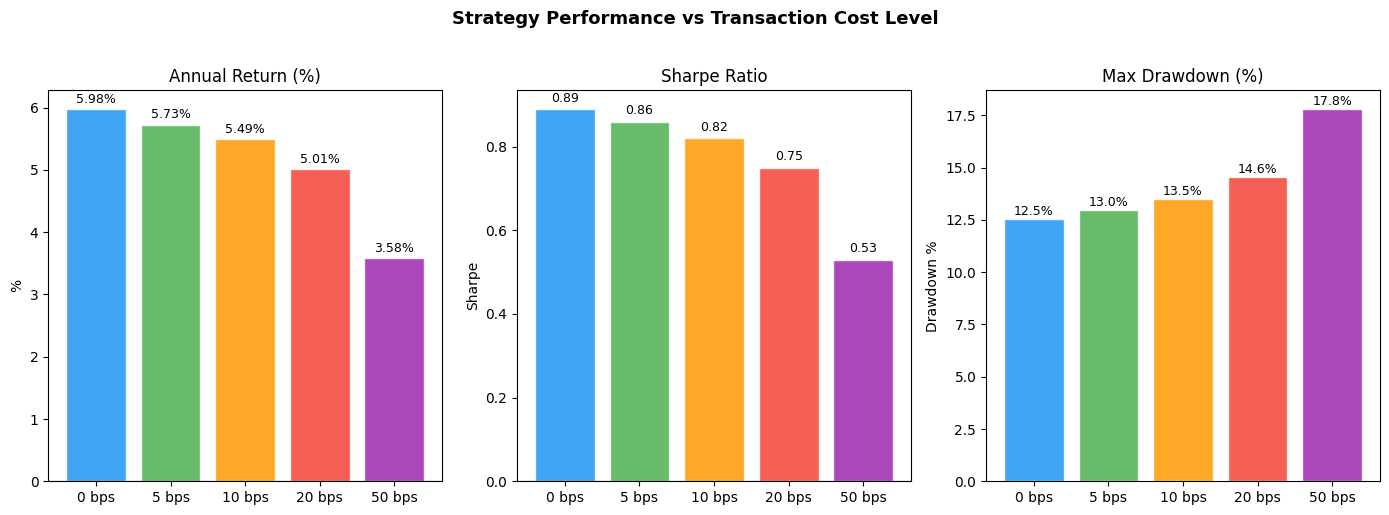

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

x = np.arange(len(costdf))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

# Annual return
axes[0].bar(x, costdf['annret%'], color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('Annual Return (%)')
axes[0].set_ylabel('%')
axes[0].set_xticks(x)
axes[0].set_xticklabels(costdf.index, rotation=0)
axes[0].axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(costdf['annret%']):
    axes[0].text(i, v + 0.05, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

# Sharpe
axes[1].bar(x, costdf['sharpe'], color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Sharpe Ratio')
axes[1].set_ylabel('Sharpe')
axes[1].set_xticks(x)
axes[1].set_xticklabels(costdf.index, rotation=0)
axes[1].axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(costdf['sharpe']):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# Max Drawdown
axes[2].bar(x, costdf['maxdd%'].abs(), color=colors, alpha=0.85, edgecolor='white')
axes[2].set_title('Max Drawdown (%)')
axes[2].set_ylabel('Drawdown %')
axes[2].set_xticks(x)
axes[2].set_xticklabels(costdf.index, rotation=0)
for i, v in enumerate(costdf['maxdd%'].abs()):
    axes[2].text(i, v + 0.05, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('Strategy Performance vs Transaction Cost Level',  fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Mean turnover per rebalance  : 38.1%
Median turnover              : 19.5%
Max turnover                 : 181.8%
Annualized turnover          : 457.2% per year


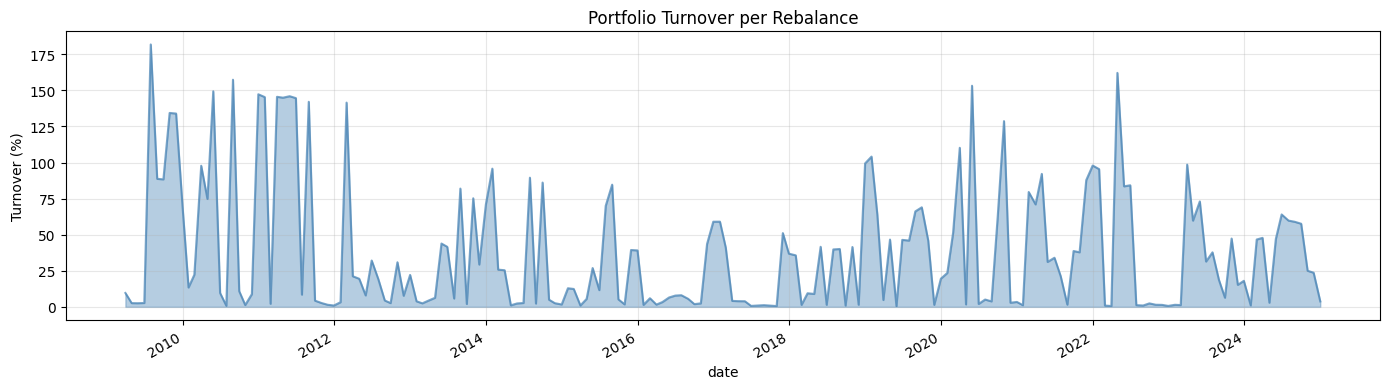

In [17]:
rebalanceturnover = []
for i, d in enumerate(targetwtsdf.index):
    if d not in actualwts.index or i == 0:
        continue
    tw = targetwtsdf.iloc[i].values
    idx = actualwts.index.get_loc(d)
    pw = actualwts.iloc[idx - 1].values
    to = np.abs(tw - pw).sum()
    rebalanceturnover.append({'date': d, 'turnover': to})

turnoverdf = pd.DataFrame(rebalanceturnover).set_index('date')

print(f'Mean turnover per rebalance  : {turnoverdf["turnover"].mean()*100:.1f}%')
print(f'Median turnover              : {turnoverdf["turnover"].median()*100:.1f}%')
print(f'Max turnover                 : {turnoverdf["turnover"].max()*100:.1f}%')
print(f'Annualized turnover          : {turnoverdf["turnover"].mean()*12*100:.1f}% per year')

fig, axes = plt.subplots(figsize=(14, 4))
turnoverpct = turnoverdf['turnover'] * 100
turnoverpct.plot(ax=axes, color='steelblue', alpha=0.7)
axes.fill_between(turnoverdf.index, 0, turnoverpct.values, alpha=0.4, color='steelblue')
axes.set_title('Portfolio Turnover per Rebalance')
axes.set_ylabel('Turnover (%)')
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
netrets = applycosts(grossrets, actualwts, targetwtsdf, bps=10)
bmark6040 = pd.read_csv(results / 'benchmark6040.csv', index_col=0, parse_dates=True).squeeze()

annualperf = pd.DataFrame({
    'Strategy': netrets.resample('YE').apply(lambda x: (1+x).prod() - 1) * 100,
    '60/40': bmark6040.resample('YE').apply(lambda x: (1+x).prod() - 1) * 100,
})
annualperf['Outperformance'] = annualperf['Strategy'] - annualperf['60/40']
annualperf.index = annualperf.index.year
print(annualperf.round(2).to_string())

      Strategy  60/40  Outperformance
Date                                 
2009      7.45  23.89          -16.44
2010     11.40  13.85           -2.45
2011     13.78  15.10           -1.32
2012      0.10  10.79          -10.68
2013     -1.54  12.16          -13.70
2014     10.57  18.93           -8.36
2015     -3.99   0.56           -4.56
2016      4.68   8.08           -3.40
2017     11.04  16.60           -5.57
2018     -0.52  -2.87            2.36
2019     14.19  24.90          -10.71
2020      6.77  19.91          -13.14
2021      4.62  14.46           -9.85
2022    -10.89 -23.38           12.48
2023      7.59  16.39           -8.80
2024     15.70  10.70            5.00


In [ ]:
costdf.to_csv(results / 'sensitivitycosts.csv')
turnoverdf.to_csv(results / 'turnover.csv')
annualperf.to_csv(results / 'annualperformance.csv')

Sensitivity results saved.
